# Tournament Simulation

In this notebook, we use the trained Poisson models to simulate the full 2026 World Cup.

The goal is to:

1. Load the trained home-goals and away-goals models
2. Build match-level predictions for any two teams
3. Simulate group-stage matches
4. Rank teams inside each group
5. Simulate the knockout bracket
6. Run the tournament many times using Monte Carlo simulation
7. Estimate each team's probability of reaching each stage

In [2]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path

# Section 1: Load models and data

In [3]:
# Project paths
DATA_DIR = Path("../data")
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REFERENCE_DIR = DATA_DIR / "reference"
MODELS_DIR = Path("../models")

In [4]:
# Load trained Poisson models
with open(MODELS_DIR / "poisson_home.pkl", "rb") as f:
    model_home = pickle.load(f)

with open(MODELS_DIR / "poisson_away.pkl", "rb") as f:
    model_away = pickle.load(f)

# Load feature column order used during training
with open(MODELS_DIR / "feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)

print("Models loaded successfully.")
print(f"Number of model features: {len(feature_columns)}")

Models loaded successfully.
Number of model features: 17


In [5]:
# Core datasets
df_historical = pd.read_csv(INTERIM_DIR / "historical_matches.csv")
df_fixtures = pd.read_csv(INTERIM_DIR / "wc2026_fixtures.csv")

# Processed feature datasets
df_match_features = pd.read_csv(PROCESSED_DIR / "df_match_features.csv")
df_form = pd.read_csv(PROCESSED_DIR / "df_form_2026.csv")
df_h2h = pd.read_csv(PROCESSED_DIR / "df_h2h_2026.csv")

# Reference datasets
df_confederations = pd.read_csv(REFERENCE_DIR / "FIFA_confederations.csv")
df_knockout = pd.read_csv(REFERENCE_DIR / "fixtures_knockout_wc2026.csv")
df_groups = pd.read_csv(REFERENCE_DIR / "group_stages.csv", sep=";")

# FIFA ranking reference
df_fifa_rank = pd.read_csv(DATA_DIR / "raw" / "wc_2026_48_teams_fifa_rank_change_corrected.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [6]:
# Inspect shape
datasets = {
    "historical_matches": df_historical,
    "wc2026_fixtures": df_fixtures,
    "df_match_features": df_match_features,
    "df_form_2026": df_form,
    "df_h2h_2026": df_h2h,
    "FIFA_confederations": df_confederations,
    "group_stages": df_groups,
    "fixtures_knockout_wc2026": df_knockout,
    "fifa_rank_2026": df_fifa_rank,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

historical_matches: (49215, 9)
wc2026_fixtures: (72, 9)
df_match_features: (49048, 16)
df_form_2026: (48, 2)
df_h2h_2026: (565, 4)
FIFA_confederations: (48, 2)
group_stages: (48, 3)
fixtures_knockout_wc2026: (32, 8)
fifa_rank_2026: (48, 4)


In [7]:
# Inspect columns
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


historical_matches
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

wc2026_fixtures
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

df_match_features
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'home_elo_pre', 'away_elo_pre', 'elo_diff', 'tournament_weight', 'is_competitive', 'home_confederation', 'away_confederation']

df_form_2026
['team', 'form_score']

df_h2h_2026
['team_a', 'team_b', 'h2h_score', 'n_meetings_analysed']

FIFA_confederations
['nation', 'confederation']

group_stages
['group', 'position', 'nation']

fixtures_knockout_wc2026
['match_id', 'round', 'match_date', 'match_time', 'home_slot', 'away_slot', 'winner_advances_to', 'loser_advances_to']

fifa_rank_2026
['Nation', 'FIFA_2022_ranking', 'FIFA_2026_rank', 'rank_change']


In [8]:
# Check number of World Cup teams
teams_from_groups = set(df_groups["nation"])
teams_from_confederations = set(df_confederations["nation"])
teams_from_form = set(df_form["team"])
teams_from_fifa = set(df_fifa_rank["Nation"])

print("Teams in group_stages:", len(teams_from_groups))
print("Teams in confederations:", len(teams_from_confederations))
print("Teams in form table:", len(teams_from_form))
print("Teams in FIFA ranking table:", len(teams_from_fifa))

# Check missing teams across key reference tables
print("\nTeams in groups but missing from confederations:")
print(sorted(teams_from_groups - teams_from_confederations))

print("\nTeams in groups but missing from form table:")
print(sorted(teams_from_groups - teams_from_form))

print("\nTeams in groups but missing from FIFA ranking table:")
print(sorted(teams_from_groups - teams_from_fifa))

Teams in group_stages: 48
Teams in confederations: 48
Teams in form table: 48
Teams in FIFA ranking table: 48

Teams in groups but missing from confederations:
[]

Teams in groups but missing from form table:
[]

Teams in groups but missing from FIFA ranking table:
[]


In [9]:
display(df_fixtures.head())
display(df_groups.head())
display(df_knockout.head())
display(df_match_features.head())

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
1,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True
2,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False
3,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False
4,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True


,group,position,nation
0,A,1,Mexico
1,A,2,South Africa
2,A,3,South Korea
3,A,4,Czech Republic
4,B,1,Canada


,match_id,round,match_date,match_time,home_slot,away_slot,winner_advances_to,loser_advances_to
0,M73,R32,2026-06-28,20:00,2A,2B,M90,NaN
1,M74,R32,2026-06-29,21:30,1E,3ABCDF,M89,NaN
2,M75,R32,2026-06-30,02:00,1F,2C,M90,NaN
3,M76,R32,2026-06-29,18:00,1C,2F,M91,NaN
4,M77,R32,2026-06-30,22:00,1I,3CDFGH,M89,NaN


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo_pre,away_elo_pre,elo_diff,tournament_weight,is_competitive,home_confederation,away_confederation
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1500.000000,1500.000000,0.000000,1,False,UEFA,UEFA
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1502.801300,1497.198700,5.602600,1,False,UEFA,UEFA
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1486.622531,1513.377469,-26.754938,1,False,UEFA,UEFA
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1505.454946,1494.545054,10.909891,1,False,UEFA,UEFA
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1497.633108,1502.366892,-4.733783,1,False,UEFA,UEFA


#
----

# Section 2: create lookup tables for Elo, form, H2H, and confederation.

The aim here is to make it easy to fetch, for any team:
- Elo rating
- confederation
- recent form score
- FIFA rank
- H2H score against another team

## 2.1— Create lookup tables

Before we can predict any 2026 match, we need quick lookup tables for team-level and matchup-level information.

In this section, we create:

- latest Elo rating per team
- team-to-confederation mapping
- team-to-form-score mapping
- team-to-FIFA-rank mapping
- head-to-head lookup between two teams

These lookup tables will make the prediction and simulation functions much cleaner.

In [10]:
#### prepare latest Elo per team

# Make sure dates are treated as dates
df_match_features["date"] = pd.to_datetime(df_match_features["date"])

# Home-team Elo records
home_elo = df_match_features[["date", "home_team", "home_elo_pre"]].rename(
    columns={
        "home_team": "team",
        "home_elo_pre": "elo"
    }
)

# Away-team Elo records
away_elo = df_match_features[["date", "away_team", "away_elo_pre"]].rename(
    columns={
        "away_team": "team",
        "away_elo_pre": "elo"
    }
)

# Combine home and away Elo records
df_team_elo = pd.concat([home_elo, away_elo], ignore_index=True)

# Get latest available Elo before the 2026 tournament
df_latest_elo = (
    df_team_elo
    .sort_values("date")
    .drop_duplicates(subset="team", keep="last")
    .reset_index(drop=True)
)

team_to_elo = dict(zip(df_latest_elo["team"], df_latest_elo["elo"]))

df_latest_elo.tail()

,date,team,elo
317,2026-03-31,Republic of Ireland,1748.177082
318,2026-03-31,Russia,1840.274201
319,2026-03-31,Spain,2229.756779
320,2026-03-31,Curaçao,1621.162116
321,2026-03-31,Comoros,1488.747627


In [11]:
df_latest_elo.sort_values("elo", ascending=False).head(13)

,date,team,elo
319,2026-03-31,Spain,2229.756779
295,2026-03-31,Argentina,2179.651451
197,2026-03-29,France,2124.778622
296,2026-03-31,England,2094.723009
207,2026-03-29,Colombia,2064.025447
292,2026-03-31,Brazil,2050.192145
248,2026-03-31,Portugal,2023.470091
298,2026-03-31,Netherlands,2019.419663
270,2026-03-31,Ecuador,2015.364338
255,2026-03-31,Croatia,1994.757090


In [12]:
#### create confederation lookup

team_to_confederation = dict(
    zip(df_confederations["nation"], df_confederations["confederation"])
)

list(team_to_confederation.items())[:5]

[('France', 'UEFA'),
 ('Spain', 'UEFA'),
 ('England', 'UEFA'),
 ('Portugal', 'UEFA'),
 ('Netherlands', 'UEFA')]

In [13]:
#### create form lookup (last 10 games goal differential)

team_to_form = dict(
    zip(df_form["team"], df_form["form_score"])
)

list(team_to_form.items())[:5]

[('Morocco', 63.0),
 ('Japan', 61.0),
 ('Spain', 59.0),
 ('Portugal', 56.0),
 ('England', 54.0)]

In [14]:
#### create FIFA ranking lookup as of 2026

team_to_fifa_rank = dict(
    zip(df_fifa_rank["Nation"], df_fifa_rank["FIFA_2026_rank"])
)

team_to_fifa_rank_change = dict(
    zip(df_fifa_rank["Nation"], df_fifa_rank["rank_change"])
)

list(team_to_fifa_rank.items())[:8]

[('France', 1),
 ('Spain', 2),
 ('Argentina', 3),
 ('England', 4),
 ('Portugal', 5),
 ('Brazil', 6),
 ('Netherlands', 7),
 ('Morocco', 8)]

In [15]:
#### create H2H helper function

def get_h2h_score(team_a, team_b):
    """
    Return the head-to-head score from team_a's perspective.

    Example:
    If Argentina vs Brazil = +6,
    then Brazil vs Argentina = -6.
    """

    direct_match = df_h2h[
        (df_h2h["team_a"] == team_a) &
        (df_h2h["team_b"] == team_b)
    ]

    if len(direct_match) > 0:
        return direct_match["h2h_score"].iloc[0]

    reverse_match = df_h2h[
        (df_h2h["team_a"] == team_b) &
        (df_h2h["team_b"] == team_a)
    ]

    if len(reverse_match) > 0:
        return -reverse_match["h2h_score"].iloc[0]

    return 0

In [16]:
#### test H2H helper (team head to head, only looks at last 5 games but gives 0 for teams that only played 1 or 2 games)

test_pairs = [
    ("Argentina", "Brazil"),
    ("Brazil", "Argentina"),
    ("France", "Spain"),
    ("Spain", "France"),
    ("France", "Senegal"),
    ("Algeria", "Morocco")
]

for team_a, team_b in test_pairs:
    print(f"{team_a} vs {team_b}: {get_h2h_score(team_a, team_b)}")

Argentina vs Brazil: 6.0
Brazil vs Argentina: -6.0
France vs Spain: -2.0
Spain vs France: 2.0
France vs Senegal: 0.0
Algeria vs Morocco: -6.0


In [17]:
#### sanity check all World Cup teams have lookup values

wc_teams = sorted(df_groups["nation"].unique())

missing_elo = [team for team in wc_teams if team not in team_to_elo]
missing_confederation = [team for team in wc_teams if team not in team_to_confederation]
missing_form = [team for team in wc_teams if team not in team_to_form]
missing_fifa_rank = [team for team in wc_teams if team not in team_to_fifa_rank]

print("Missing Elo:", missing_elo)
print("Missing confederation:", missing_confederation)
print("Missing form:", missing_form)
print("Missing FIFA rank:", missing_fifa_rank)

Missing Elo: []
Missing confederation: []
Missing form: []
Missing FIFA rank: []


In [18]:
#### inspect one team profile

sample_team = "Morocco"

team_profile = {
    "team": sample_team,
    "elo": team_to_elo.get(sample_team),
    "confederation": team_to_confederation.get(sample_team),
    "form_score": team_to_form.get(sample_team),
    "fifa_rank": team_to_fifa_rank.get(sample_team),
    "rank_change": team_to_fifa_rank_change.get(sample_team),
}

team_profile

{'team': 'Morocco',
 'elo': 1972.941440105271,
 'confederation': 'CAF',
 'form_score': 63.0,
 'fifa_rank': 8,
 'rank_change': 3}

#### Choice:
- Keep the prediction model pure. Use only the features it was trained and validated on. 
- Use FIFA rank, form, and H2H only for dashboard context and explanations.

#### Use the model for probabilities
Poisson model:
- Elo + match context → expected goals → win/draw/loss probabilities

#### Use the extra football context for interpretation:
Dashboard explanation:
- FIFA rank, rank change, recent form, H2H, confederation, Elo difference

PS: I also calculated recent form, FIFA rankings, and head-to-head records. But I did not feed them into the model because they were not part of the validated training setup. Instead, I use them in the dashboard to explain each matchup alongside the model probabilities

#
----

# Section 3 - Build match prediction system

## 3.1 — Build match prediction function

Now that the lookup tables are ready, we can create a prediction function for any 2026 matchup.

The model only uses the features it was trained on:

- home Elo
- away Elo
- Elo difference
- tournament weight
- neutral venue
- home confederation
- away confederation

The function will:

1. Build a one-row feature table
2. One-hot encode categorical columns
3. Align the columns with `feature_columns.pkl`
4. Predict expected goals using the two Poisson models
5. Convert expected goals into win/draw/loss probabilities

## Build Model feature row

In [19]:
def build_match_features(home_team, away_team, neutral=True, tournament_weight=5):
    """
    Build one prediction row for a 2026 World Cup match.

    This function only includes the features used during model training.
    """

    home_elo = team_to_elo.get(home_team)
    away_elo = team_to_elo.get(away_team)

    home_conf = team_to_confederation.get(home_team)
    away_conf = team_to_confederation.get(away_team)

    if home_elo is None:
        raise ValueError(f"Missing Elo rating for {home_team}")

    if away_elo is None:
        raise ValueError(f"Missing Elo rating for {away_team}")

    if home_conf is None:
        raise ValueError(f"Missing confederation for {home_team}")

    if away_conf is None:
        raise ValueError(f"Missing confederation for {away_team}")

    row = pd.DataFrame([{
        "home_elo_pre": home_elo,
        "away_elo_pre": away_elo,
        "elo_diff": home_elo - away_elo,
        "tournament_weight": tournament_weight,
        "neutral": int(neutral),
        "home_confederation": home_conf,
        "away_confederation": away_conf
    }])

    # One-hot encode categorical variables
    X = pd.get_dummies(row)

    # Align with training columns
    X = X.reindex(columns=feature_columns, fill_value=0)

    # Important: statsmodels intercept column must be 1
    if "const" in X.columns:
        X["const"] = 1

    # Make sure all model inputs are numeric
    X = X.astype(float)

    return X

- It creates the exact one-row input table that the trained Poisson model expects.

- It is not predicting yet. It is only preparing the features.

In [20]:
#### test feature builder

X_test = build_match_features("Argentina", "Brazil")

print(X_test.shape)
display(X_test)

(1, 17)


,const,home_elo_pre,away_elo_pre,tournament_weight,neutral,home_confederation_CAF,home_confederation_CONCACAF,home_confederation_CONMEBOL,home_confederation_OFC,home_confederation_UEFA,home_confederation_Unknown,away_confederation_CAF,away_confederation_CONCACAF,away_confederation_CONMEBOL,away_confederation_OFC,away_confederation_UEFA,away_confederation_Unknown
0,1.0,2179.651451,2050.192145,5.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## create Poisson probability function

In [21]:
from scipy.stats import poisson

In [22]:
def predict_match(home_team, away_team, neutral=True, tournament_weight=5, max_goals=10):
    """
    Predict expected goals and win/draw/loss probabilities for one match.
    """

    X = build_match_features(
        home_team=home_team,
        away_team=away_team,
        neutral=neutral,
        tournament_weight=tournament_weight
    )

    home_xg = model_home.predict(X)[0]
    away_xg = model_away.predict(X)[0]

    score_probs = []

    home_win_prob = 0
    draw_prob = 0
    away_win_prob = 0

    for home_goals in range(max_goals + 1):
        for away_goals in range(max_goals + 1):

            prob = (
                poisson.pmf(home_goals, home_xg) *
                poisson.pmf(away_goals, away_xg)
            )

            score_probs.append({
                "home_goals": home_goals,
                "away_goals": away_goals,
                "probability": prob
            })

            if home_goals > away_goals:
                home_win_prob += prob
            elif home_goals == away_goals:
                draw_prob += prob
            else:
                away_win_prob += prob

    score_probs = pd.DataFrame(score_probs)

    return {
        "home_team": home_team,
        "away_team": away_team,
        "home_xg": home_xg,
        "away_xg": away_xg,
        "home_win_prob": home_win_prob,
        "draw_prob": draw_prob,
        "away_win_prob": away_win_prob,
        "score_probs": score_probs
    }

## Test Predictions

In [23]:
test_matches = [
    ("Argentina", "Brazil"),
    ("France", "Spain"),
    ("Morocco", "Portugal"),
    ("England", "Iran"),
    ("Mexico", "South Africa")
]

for home_team, away_team in test_matches:
    pred = predict_match(home_team, away_team)

    print(f"\n{home_team} vs {away_team}")
    print(f"Home xG: {pred['home_xg']:.2f}")
    print(f"Away xG: {pred['away_xg']:.2f}")
    print(f"Home win: {pred['home_win_prob']:.1%}")
    print(f"Draw: {pred['draw_prob']:.1%}")
    print(f"Away win: {pred['away_win_prob']:.1%}")


Argentina vs Brazil
Home xG: 1.36
Away xG: 0.82
Home win: 49.4%
Draw: 27.9%
Away win: 22.7%

France vs Spain
Home xG: 0.77
Away xG: 1.48
Home win: 19.4%
Draw: 26.4%
Away win: 54.2%

Morocco vs Portugal
Home xG: 0.93
Away xG: 1.04
Home win: 31.4%
Draw: 31.1%
Away win: 37.5%

England vs Iran
Home xG: 1.26
Away xG: 0.83
Home win: 46.3%
Draw: 29.1%
Away win: 24.6%

Mexico vs South Africa
Home xG: 2.11
Away xG: 0.48
Home win: 75.7%
Draw: 17.2%
Away win: 7.1%


In [24]:
df_latest_elo.sort_values("elo", ascending=False).head(3)

,date,team,elo
319,2026-03-31,Spain,2229.756779
295,2026-03-31,Argentina,2179.651451
197,2026-03-29,France,2124.778622


In [25]:
#### test H2H helper (team head to head, only looks at last 5 games but gives 0 for teams that only played 1 or 2 games)

test_pairs = [
    ("France", "Spain"),
    ("Portugal", "Morocco")
]

for team_a, team_b in test_pairs:
    print(f"{team_a} vs {team_b}: {get_h2h_score(team_a, team_b)}")

France vs Spain: -2.0
Portugal vs Morocco: -2.0


## inspect most likely scorelines

In [26]:
pred = predict_match("Argentina", "Brazil")

pred["score_probs"].sort_values(
    "probability",
    ascending=False
).head(10)

,home_goals,away_goals,probability
11,1,0,0.153658
12,1,1,0.126244
0,0,0,0.113325
22,2,0,0.104173
1,0,1,0.093107
23,2,1,0.085587
13,1,2,0.051860
33,3,0,0.047083
34,3,1,0.038683
2,0,2,0.038248


In [27]:
pred = predict_match("Portugal", "Morocco")

pred["score_probs"].sort_values(
    "probability",
    ascending=False
).head(10)

,home_goals,away_goals,probability
11,1,0,0.135903
12,1,1,0.135311
0,0,0,0.133433
1,0,1,0.132852
22,2,0,0.069209
23,2,1,0.068908
13,1,2,0.067361
2,0,2,0.066137
24,2,2,0.034304
33,3,0,0.023497


In [28]:
pred["home_win_prob"] + pred["draw_prob"] + pred["away_win_prob"]

np.float64(0.9999999782963269)

- The win/draw/loss probabilities sum to almost 1.
- The most likely scorelines are realistic for the predicted expected goals.
- This suggests the prediction function is working as expected.

#
-----

# Section 4 — simulate a single match.

## 4.1 — Simulate a single match

Now that we can predict expected goals for any matchup, we can simulate one match result.

The logic is:

1. Use the Poisson model to predict expected goals for each team
2. Sample actual goals from each team's Poisson distribution
3. Return the score and match result

For group-stage matches, draws are allowed.
Knockout matches will need extra logic later because one team must advance.

In [29]:
def simulate_match(home_team, away_team, neutral=True, tournament_weight=5, random_state=None):
    """
    Simulate one football match using the predicted expected goals.

    For group-stage matches:
    - home win is allowed
    - draw is allowed
    - away win is allowed
    """

    if random_state is not None:
        np.random.seed(random_state)

    pred = predict_match(
        home_team=home_team,
        away_team=away_team,
        neutral=neutral,
        tournament_weight=tournament_weight
    )

    home_xg = pred["home_xg"]
    away_xg = pred["away_xg"]

    home_goals = np.random.poisson(home_xg)
    away_goals = np.random.poisson(away_xg)

    if home_goals > away_goals:
        result = "H"
        winner = home_team
    elif home_goals < away_goals:
        result = "A"
        winner = away_team
    else:
        result = "D"
        winner = None

    return {
        "home_team": home_team,
        "away_team": away_team,
        "home_xg": home_xg,
        "away_xg": away_xg,
        "home_goals": home_goals,
        "away_goals": away_goals,
        "result": result,
        "winner": winner
    }

In [30]:
#### Test one match

simulate_match("Argentina", "Brazil", random_state=16)

{'home_team': 'Argentina',
 'away_team': 'Brazil',
 'home_xg': np.float64(1.3559041758011838),
 'away_xg': np.float64(0.8215896270684804),
 'home_goals': 0,
 'away_goals': 1,
 'result': 'A',
 'winner': 'Brazil'}

In [31]:
simulate_match("Argentina", "Brazil", random_state=42)

{'home_team': 'Argentina',
 'away_team': 'Brazil',
 'home_xg': np.float64(1.3559041758011838),
 'away_xg': np.float64(0.8215896270684804),
 'home_goals': 3,
 'away_goals': 0,
 'result': 'H',
 'winner': 'Argentina'}

- One simulated match can look surprising. That is normal.

- The whole point of Monte Carlo is that we do not trust one run. We run the tournament thousands of times, then count the patterns.

## Simulate the same match multiple times

In [32]:
for i in range(10):
    match = simulate_match("Argentina", "Brazil")

    print(
        f"{match['home_team']} {match['home_goals']} - "
        f"{match['away_goals']} {match['away_team']} | "
        f"Result: {match['result']}"
    )

Argentina 0 - 0 Brazil | Result: D
Argentina 3 - 2 Brazil | Result: H
Argentina 0 - 0 Brazil | Result: D
Argentina 1 - 0 Brazil | Result: H
Argentina 1 - 0 Brazil | Result: H
Argentina 1 - 1 Brazil | Result: D
Argentina 0 - 1 Brazil | Result: A
Argentina 0 - 1 Brazil | Result: A
Argentina 0 - 3 Brazil | Result: A
Argentina 0 - 1 Brazil | Result: A


## Test a few different match-ups

In [33]:
sample_matches = [
    ("Argentina", "Brazil"),
    ("France", "Spain"),
    ("Morocco", "Portugal"),
    ("England", "Iran"),
    ("Mexico", "South Africa")
]

for home_team, away_team in sample_matches:
    match = simulate_match(home_team, away_team)

    print(
        f"{match['home_team']} {match['home_goals']} - "
        f"{match['away_goals']} {match['away_team']} "
        f"| xG: {match['home_xg']:.2f} - {match['away_xg']:.2f} "
        f"| Result: {match['result']}"
    )

Argentina 0 - 1 Brazil | xG: 1.36 - 0.82 | Result: A
France 1 - 1 Spain | xG: 0.77 - 1.48 | Result: D
Morocco 1 - 0 Portugal | xG: 0.93 - 1.04 | Result: H
England 6 - 0 Iran | xG: 1.26 - 0.83 | Result: H
Mexico 0 - 0 South Africa | xG: 2.11 - 0.48 | Result: D


In [34]:
### Simulate 10,000 times to see if averages make sense

results = []

for i in range(10_000):
    match = simulate_match("Argentina", "Brazil")
    results.append(match["result"])

pd.Series(results).value_counts(normalize=True).sort_index()

A    0.2274
D    0.2842
H    0.4884
Name: proportion, dtype: float64

The single-match outputs will look noisy. That is the whole point of simulation. What matters is that thousands of simulated matches average out to the model probabilities.

So now we have confirmed three things:

1. predict_match() gives sensible xG and probabilities.
2. simulate_match() creates random match outcomes correctly.
3. Repeating the same match many times converges back to the model probabilities.

- ##### One small note: 10_000 took 42 seconds, which is slow because each simulation calls predict_match() again. Later, for the full tournament, we should avoid recalculating xG every time where possible.

# 
-----

# Section 5 — simulate the group stage.

## 5.1 — Simulate the group stage

Now we simulate the 72 group-stage matches.

For each match, we will:

1. Simulate the score using `simulate_match()`
2. Award points
3. Update goals for, goals against, and goal difference
4. Build one table per group
5. Rank teams using points, goal difference, and goals scored

For this first version, if teams are still tied after those rules, we use a random tie-breaker.

## add group information to fixtures

In [35]:
# Team to group lookup
team_to_group = dict(zip(df_groups["nation"], df_groups["group"]))

# Add group to each group-stage fixture
df_group_fixtures = df_fixtures.copy()

df_group_fixtures["group"] = df_group_fixtures["home_team"].map(team_to_group)

# Basic check
display(df_group_fixtures.head())
print(df_group_fixtures["group"].value_counts().sort_index())

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,group
0,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False,A
1,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True,A
2,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False,B
3,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False,D
4,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True,B


group
A    6
B    6
C    6
D    6
E    6
F    6
G    6
H    6
I    6
J    6
K    6
L    6
Name: count, dtype: int64


Why 6 games per group:
- Team 1 vs Team 2
- Team 1 vs Team 3
- Team 1 vs Team 4
- Team 2 vs Team 3
- Team 2 vs Team 4
- Team 3 vs Team 4

In [36]:
#### check every fixture has a group

missing_group_fixtures = df_group_fixtures[df_group_fixtures["group"].isna()]

print("Fixtures with missing group:", len(missing_group_fixtures))
display(missing_group_fixtures)

Fixtures with missing group: 0


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,group


## create empty group table

In [37]:
#### create empty group table

def create_empty_group_table(group_teams):
    """
    Create an empty standings table for one group.
    """

    table = pd.DataFrame({
        "team": group_teams,
        "played": 0,
        "wins": 0,
        "draws": 0,
        "losses": 0,
        "goals_for": 0,
        "goals_against": 0,
        "goal_difference": 0,
        "points": 0
    })

    return table

## Update table after 1 Match

In [38]:
def update_group_table(table, match):
    """
    Update a group table after one simulated match.
    """

    home_team = match["home_team"]
    away_team = match["away_team"]
    home_goals = match["home_goals"]
    away_goals = match["away_goals"]

    # Update played
    table.loc[table["team"] == home_team, "played"] += 1
    table.loc[table["team"] == away_team, "played"] += 1

    # Update goals
    table.loc[table["team"] == home_team, "goals_for"] += home_goals
    table.loc[table["team"] == home_team, "goals_against"] += away_goals

    table.loc[table["team"] == away_team, "goals_for"] += away_goals
    table.loc[table["team"] == away_team, "goals_against"] += home_goals

    # Update result stats and points
    if home_goals > away_goals:
        table.loc[table["team"] == home_team, "wins"] += 1
        table.loc[table["team"] == away_team, "losses"] += 1

        table.loc[table["team"] == home_team, "points"] += 3

    elif home_goals < away_goals:
        table.loc[table["team"] == away_team, "wins"] += 1
        table.loc[table["team"] == home_team, "losses"] += 1

        table.loc[table["team"] == away_team, "points"] += 3

    else:
        table.loc[table["team"] == home_team, "draws"] += 1
        table.loc[table["team"] == away_team, "draws"] += 1

        table.loc[table["team"] == home_team, "points"] += 1
        table.loc[table["team"] == away_team, "points"] += 1

    # Recalculate goal difference
    table["goal_difference"] = table["goals_for"] - table["goals_against"]

    return table

## rank one group table

In [39]:
def rank_group_table(table):
    """
    Rank teams in a group.

    Main rules:
    1. Points
    2. Goal difference
    3. Goals scored
    4. Random tie-breaker
    """

    table = table.copy()

    # Temporary random tie-breaker for exact ties
    table["random_tiebreaker"] = np.random.random(len(table))

    table = (
        table
        .sort_values(
            by=["points", "goal_difference", "goals_for", "random_tiebreaker"],
            ascending=[False, False, False, False]
        )
        .reset_index(drop=True)
    )

    table["group_rank"] = table.index + 1

    table = table.drop(columns=["random_tiebreaker"])

    return table

## simulate one full group

In [40]:
def simulate_group(group_name):
    """
    Simulate all matches in one group and return the ranked group table.
    """

    group_teams = (
        df_groups[df_groups["group"] == group_name]
        .sort_values("position")["nation"]
        .tolist()
    )

    group_matches = df_group_fixtures[df_group_fixtures["group"] == group_name]

    table = create_empty_group_table(group_teams)

    simulated_matches = []

    for _, row in group_matches.iterrows():
        match = simulate_match(
            home_team=row["home_team"],
            away_team=row["away_team"],
            neutral=row["neutral"]
        )

        simulated_matches.append(match)
        table = update_group_table(table, match)

    ranked_table = rank_group_table(table)
    ranked_table["group"] = group_name

    return ranked_table, pd.DataFrame(simulated_matches)

## test one group

In [41]:
group_a_table, group_a_matches = simulate_group("C")

display(group_a_matches)
display(group_a_table)

,home_team,away_team,home_xg,away_xg,home_goals,away_goals,result,winner
0,Brazil,Morocco,1.196691,0.777093,0,2,A,Morocco
1,Haiti,Scotland,1.058296,1.283642,1,2,A,Scotland
2,Scotland,Morocco,0.743416,1.489087,0,0,D,NaN
3,Brazil,Haiti,2.245960,0.589181,0,0,D,NaN
4,Scotland,Brazil,0.681838,2.062838,3,1,H,Scotland
5,Morocco,Haiti,1.766992,0.635292,0,0,D,NaN


,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points,group_rank,group
0,Scotland,3,2,1,0,5,2,3,7,1,C
1,Morocco,3,1,2,0,2,0,2,5,2,C
2,Haiti,3,0,2,1,1,2,-1,2,3,C
3,Brazil,3,0,1,2,1,5,-4,1,4,C


## Run 1000 iterations on 1 group 

In [42]:
group_c_rank_results = []

for i in range(1000):
    group_table, group_matches = simulate_group("C")

    group_c_rank_results.append(
        group_table[["team", "group_rank"]]
    )

df_group_c_ranks = pd.concat(group_c_rank_results, ignore_index=True)

group_c_rank_probs = (
    df_group_c_ranks
    .groupby(["team", "group_rank"])
    .size()
    .reset_index(name="count")
)

group_c_rank_probs["probability"] = group_c_rank_probs["count"] / 1000

group_c_rank_probs_pivot = (
    group_c_rank_probs
    .pivot(index="team", columns="group_rank", values="probability")
    .fillna(0)
)

group_c_rank_probs_pivot.columns = [
    f"rank_{int(col)}_prob" for col in group_c_rank_probs_pivot.columns
]

group_c_rank_probs_pivot.sort_values("rank_1_prob", ascending=False)

,rank_1_prob,rank_2_prob,rank_3_prob,rank_4_prob
team,,,,
Brazil,0.586,0.299,0.091,0.024
Morocco,0.313,0.417,0.180,0.090
Scotland,0.065,0.173,0.407,0.355
Haiti,0.036,0.111,0.322,0.531


## Group stage full 12 Group simulation

In [43]:
def simulate_group_stage():
    """
    Simulate all 12 groups and return:
    - full ranked group tables
    - all simulated group-stage matches
    """

    all_group_tables = []
    all_group_matches = []

    for group_name in sorted(df_groups["group"].unique()):
        group_table, group_matches = simulate_group(group_name)

        all_group_tables.append(group_table)
        all_group_matches.append(group_matches)

    df_group_tables = pd.concat(all_group_tables, ignore_index=True)
    df_group_matches = pd.concat(all_group_matches, ignore_index=True)

    return df_group_tables, df_group_matches

In [44]:
#### only creates one random tournament group-stage sample 

df_group_tables, df_group_matches = simulate_group_stage()

display(df_group_matches.head())
display(df_group_tables.head())

print("Group-stage matches:", df_group_matches.shape)
print("Group tables:", df_group_tables.shape)

,home_team,away_team,home_xg,away_xg,home_goals,away_goals,result,winner
0,Mexico,South Africa,2.241780,0.328106,2,0,H,Mexico
1,South Korea,Czech Republic,1.537149,0.789380,1,1,D,NaN
2,Czech Republic,South Africa,1.280797,0.933770,2,0,H,Czech Republic
3,Mexico,South Korea,1.290889,0.576383,3,1,H,Mexico
4,Mexico,Czech Republic,1.959555,0.453907,5,0,H,Mexico


,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points,group_rank,group
0,Mexico,3,3,0,0,10,1,9,9,1,A
1,Czech Republic,3,1,1,1,3,6,-3,4,2,A
2,South Africa,3,1,0,2,1,4,-3,3,3,A
3,South Korea,3,0,1,2,2,5,-3,1,4,A
4,Canada,3,2,1,0,6,1,5,7,1,B


Group-stage matches: (72, 8)
Group tables: (48, 11)


In [45]:
#### Sanity check

print("Number of simulated group matches:", len(df_group_matches))
print("Number of teams in group tables:", len(df_group_tables))

print("\nPlayed matches per team:")
print(df_group_tables["played"].value_counts())

print("\nTeams per group:")
print(df_group_tables["group"].value_counts().sort_index())

Number of simulated group matches: 72
Number of teams in group tables: 48

Played matches per team:
played
3    48
Name: count, dtype: int64

Teams per group:
group
A    4
B    4
C    4
D    4
E    4
F    4
G    4
H    4
I    4
J    4
K    4
L    4
Name: count, dtype: int64


#
----

# Section 6 — Select qualified teams

## 6.1 — Select qualified teams

After the group stage, 32 teams qualify for the knockout stage.

The 2026 format is:

- Top 2 from each group qualify automatically
- Best 8 third-placed teams also qualify
- Total: 32 teams

In this section, we create:

- direct qualifiers: group winners and runners-up
- best third-placed teams
- a slot mapping for group winners and runners-up, such as `1A`, `2A`, `1B`, `2B`

## get direct qualifiers

In [46]:
def get_direct_qualifiers(df_group_tables):
    """
    Select group winners and runners-up.

    Returns a dictionary like:
    {
        "1A": "Mexico",
        "2A": "South Korea",
        ...
    }
    """

    direct_qualifiers = {}

    top_two = df_group_tables[df_group_tables["group_rank"].isin([1, 2])].copy()

    for _, row in top_two.iterrows():
        slot = f"{int(row['group_rank'])}{row['group']}"
        direct_qualifiers[slot] = row["team"]

    return direct_qualifiers

In [47]:
df_group_tables, df_group_matches = simulate_group_stage()

display(df_group_tables.head())
print(df_group_tables.shape)

,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points,group_rank,group
0,Mexico,3,3,0,0,7,0,7,9,1,A
1,South Africa,3,1,0,2,1,2,-1,3,2,A
2,South Korea,3,1,0,2,2,5,-3,3,3,A
3,Czech Republic,3,1,0,2,2,5,-3,3,4,A
4,Canada,3,2,1,0,5,2,3,7,1,B


(48, 11)


In [48]:
#### test direct qualifiers

direct_qualifiers = get_direct_qualifiers(df_group_tables)

print("Number of direct qualifiers:", len(direct_qualifiers))
direct_qualifiers

Number of direct qualifiers: 24


{'1A': 'Mexico',
 '2A': 'South Africa',
 '1B': 'Canada',
 '2B': 'Switzerland',
 '1C': 'Scotland',
 '2C': 'Brazil',
 '1D': 'Turkey',
 '2D': 'United States',
 '1E': 'Ecuador',
 '2E': 'Germany',
 '1F': 'Japan',
 '2F': 'Tunisia',
 '1G': 'Iran',
 '2G': 'Egypt',
 '1H': 'Spain',
 '2H': 'Saudi Arabia',
 '1I': 'Norway',
 '2I': 'Senegal',
 '1J': 'Argentina',
 '2J': 'Austria',
 '1K': 'Colombia',
 '2K': 'DR Congo',
 '1L': 'Croatia',
 '2L': 'England'}

## get best third-placed teams

In [49]:
def get_best_third_placed_teams(df_group_tables, n_teams=8):
    """
    Select the best third-placed teams.

    Ranking rules used:
    1. Points
    2. Goal difference
    3. Goals scored
    4. FIFA 2026 rank as final practical tie-breaker

    Note:
    Official rules may use fair play before FIFA ranking,
    but we do not simulate yellow/red cards in this project.
    """

    third_placed = df_group_tables[df_group_tables["group_rank"] == 3].copy()

    third_placed["fifa_rank"] = third_placed["team"].map(team_to_fifa_rank)

    best_third_placed = (
        third_placed
        .sort_values(
            by=["points", "goal_difference", "goals_for", "fifa_rank"],
            ascending=[False, False, False, True]
        )
        .head(n_teams)
        .reset_index(drop=True)
    )

    best_third_placed["third_place_rank"] = best_third_placed.index + 1

    return best_third_placed

In [50]:
best_third_placed = get_best_third_placed_teams(df_group_tables)

display(best_third_placed)

print("Number of best third-placed teams:", len(best_third_placed))

,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points,group_rank,group,fifa_rank,third_place_rank
0,Uruguay,3,2,0,1,5,5,0,6,3,H,17,1
1,Netherlands,3,1,1,1,4,2,2,4,3,F,7,2
2,Bosnia and Herzegovina,3,1,1,1,5,4,1,4,3,B,65,3
3,Morocco,3,1,1,1,4,4,0,4,3,C,8,4
4,Belgium,3,1,1,1,5,8,-3,4,3,G,9,5
5,Australia,3,1,0,2,5,5,0,3,3,D,27,6
6,France,3,1,0,2,2,2,0,3,3,I,1,7
7,Curaçao,3,1,0,2,3,4,-1,3,3,E,82,8


Number of best third-placed teams: 8


## combine qualifiers

In [51]:
def get_qualified_teams(df_group_tables):
    """
    Get all 32 teams that qualify for the knockout stage.

    Returns:
    - direct_qualifiers: dictionary for 1A, 2A, 1B, 2B...
    - best_third_placed: dataframe of the 8 best third-placed teams
    - qualified_teams: list of all 32 qualified teams
    """

    direct_qualifiers = get_direct_qualifiers(df_group_tables)
    best_third_placed = get_best_third_placed_teams(df_group_tables)

    direct_teams = list(direct_qualifiers.values())
    third_placed_teams = best_third_placed["team"].tolist()

    qualified_teams = direct_teams + third_placed_teams

    return direct_qualifiers, best_third_placed, qualified_teams

## test all qualified teams

In [52]:
direct_qualifiers, best_third_placed, qualified_teams = get_qualified_teams(df_group_tables)

print("Direct qualifiers:", len(direct_qualifiers))
print("Best third-placed teams:", len(best_third_placed))
print("Total qualified teams:", len(qualified_teams))
print("Unique qualified teams:", len(set(qualified_teams)))

display(best_third_placed)

Direct qualifiers: 24
Best third-placed teams: 8
Total qualified teams: 32
Unique qualified teams: 32


,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points,group_rank,group,fifa_rank,third_place_rank
0,Uruguay,3,2,0,1,5,5,0,6,3,H,17,1
1,Netherlands,3,1,1,1,4,2,2,4,3,F,7,2
2,Bosnia and Herzegovina,3,1,1,1,5,4,1,4,3,B,65,3
3,Morocco,3,1,1,1,4,4,0,4,3,C,8,4
4,Belgium,3,1,1,1,5,8,-3,4,3,G,9,5
5,Australia,3,1,0,2,5,5,0,3,3,D,27,6
6,France,3,1,0,2,2,2,0,3,3,I,1,7
7,Curaçao,3,1,0,2,3,4,-1,3,3,E,82,8


## create third-place group lookup

This will help in the next section when we deal with bracket slots like:
- 3ABCDF
- 3CDFGH
- 3CEFHI

In [53]:
third_place_team_to_group = dict(
    zip(best_third_placed["team"], best_third_placed["group"])
)

third_place_group_to_team = dict(
    zip(best_third_placed["group"], best_third_placed["team"])
)

print("Qualified third-place teams by group:")
third_place_group_to_team

Qualified third-place teams by group:


{'H': 'Uruguay',
 'F': 'Netherlands',
 'B': 'Bosnia and Herzegovina',
 'C': 'Morocco',
 'G': 'Belgium',
 'D': 'Australia',
 'I': 'France',
 'E': 'Curaçao'}

In [54]:
#### Final sanity check function

def check_qualification_output(direct_qualifiers, best_third_placed, qualified_teams):
    """
    Run sanity checks for knockout qualification.
    """

    print("Direct qualifier slots:", len(direct_qualifiers))
    print("Best third-placed teams:", len(best_third_placed))
    print("Total qualified teams:", len(qualified_teams))
    print("Unique qualified teams:", len(set(qualified_teams)))

    if len(direct_qualifiers) != 24:
        print("Issue: expected 24 direct qualifier slots.")

    if len(best_third_placed) != 8:
        print("Issue: expected 8 best third-placed teams.")

    if len(qualified_teams) != 32:
        print("Issue: expected 32 qualified teams.")

    if len(set(qualified_teams)) != 32:
        print("Issue: duplicate qualified teams found.")

    print("\nDirect qualifier slots:")
    for slot, team in sorted(direct_qualifiers.items()):
        print(f"{slot}: {team}")

    print("\nBest third-placed teams:")
    display(best_third_placed[[
        "team",
        "group",
        "points",
        "goal_difference",
        "goals_for",
        "third_place_rank"
    ]])

In [55]:
check_qualification_output(
    direct_qualifiers=direct_qualifiers,
    best_third_placed=best_third_placed,
    qualified_teams=qualified_teams
)

Direct qualifier slots: 24
Best third-placed teams: 8
Total qualified teams: 32
Unique qualified teams: 32

Direct qualifier slots:
1A: Mexico
1B: Canada
1C: Scotland
1D: Turkey
1E: Ecuador
1F: Japan
1G: Iran
1H: Spain
1I: Norway
1J: Argentina
1K: Colombia
1L: Croatia
2A: South Africa
2B: Switzerland
2C: Brazil
2D: United States
2E: Germany
2F: Tunisia
2G: Egypt
2H: Saudi Arabia
2I: Senegal
2J: Austria
2K: DR Congo
2L: England

Best third-placed teams:


,team,group,points,goal_difference,goals_for,third_place_rank
0,Uruguay,H,6,0,5,1
1,Netherlands,F,4,2,4,2
2,Bosnia and Herzegovina,B,4,1,5,3
3,Morocco,C,4,0,4,4
4,Belgium,G,4,-3,5,5
5,Australia,D,3,0,5,6
6,France,I,3,0,2,7
7,Curaçao,E,3,-1,3,8


#
------

# Section 7 - Build match prediction

## 7.1 — Build the Round of 32 bracket

Now that we know the 32 qualified teams, we need to fill the knockout bracket.

The bracket contains slot codes such as:

- `1A`: winner of Group A
- `2B`: runner-up of Group B
- `3ABCDF`: a third-placed team from one of those groups

For direct slots like `1A` or `2B`, the mapping is simple.

For third-place slots, we assign the best available third-placed team whose group is allowed by the slot code.

## inspect knockout bracket file

In [56]:
display(df_knockout.head())
print(df_knockout.columns.tolist())
print(df_knockout.shape)

,match_id,round,match_date,match_time,home_slot,away_slot,winner_advances_to,loser_advances_to
0,M73,R32,2026-06-28,20:00,2A,2B,M90,NaN
1,M74,R32,2026-06-29,21:30,1E,3ABCDF,M89,NaN
2,M75,R32,2026-06-30,02:00,1F,2C,M90,NaN
3,M76,R32,2026-06-29,18:00,1C,2F,M91,NaN
4,M77,R32,2026-06-30,22:00,1I,3CDFGH,M89,NaN


['match_id', 'round', 'match_date', 'match_time', 'home_slot', 'away_slot', 'winner_advances_to', 'loser_advances_to']
(32, 8)


## find Round of 32 rows

In [57]:
df_knockout["round"].value_counts()

round
R32      16
R16       8
QF        4
SF        2
3rd       1
Final     1
Name: count, dtype: int64

In [58]:
df_round_32 = df_knockout[df_knockout["round"] == "R32"].copy()

display(df_round_32)
print("Round of 32 matches:", len(df_round_32))

,match_id,round,match_date,match_time,home_slot,away_slot,winner_advances_to,loser_advances_to
0,M73,R32,2026-06-28,20:00,2A,2B,M90,NaN
1,M74,R32,2026-06-29,21:30,1E,3ABCDF,M89,NaN
2,M75,R32,2026-06-30,02:00,1F,2C,M90,NaN
3,M76,R32,2026-06-29,18:00,1C,2F,M91,NaN
4,M77,R32,2026-06-30,22:00,1I,3CDFGH,M89,NaN
5,M78,R32,2026-06-30,18:00,2E,2I,M91,NaN
6,M79,R32,2026-07-01,02:00,1A,3CEFHI,M92,NaN
7,M80,R32,2026-07-01,17:00,1L,3EHIJK,M92,NaN
8,M81,R32,2026-07-02,01:00,1D,3BEFIJ,M94,NaN
9,M82,R32,2026-07-01,21:00,1G,3AEHIJ,M94,NaN


Round of 32 matches: 16


## create third-place resolver

- This function resolves slots like: 3ABCDF

In [59]:
from itertools import permutations

def assign_third_place_slots(third_place_slots, best_third_placed):
    """
    Assign third-placed teams to all third-place bracket slots.

    This tries possible assignments and keeps the first valid one.

    A valid assignment means:
    - each third-place slot gets one team
    - the team's group is allowed by that slot
    - no team is used twice
    """

    third_teams = best_third_placed[["team", "group", "third_place_rank"]].copy()

    if len(third_place_slots) != len(third_teams):
        raise ValueError(
            f"Number of third-place slots ({len(third_place_slots)}) does not match "
            f"number of third-place teams ({len(third_teams)})."
        )

    # Try every possible order of the 8 third-placed teams
    for perm in permutations(third_teams.to_dict("records")):
        assignment = {}
        valid = True

        for slot, team_row in zip(third_place_slots, perm):
            allowed_groups = list(str(slot).replace("3", ""))

            if team_row["group"] not in allowed_groups:
                valid = False
                break

            assignment[slot] = team_row["team"]

        if valid:
            return assignment

    raise ValueError("No valid third-place assignment found.")

## build Round of 32 fixtures

In [60]:
direct_qualifiers, best_third_placed, qualified_teams = get_qualified_teams(df_group_tables)

In [61]:
def build_round_32_bracket(df_round_32, direct_qualifiers, best_third_placed):
    """
    Fill the Round of 32 bracket with real teams.

    Handles:
    - direct slots like 1A, 2B
    - third-place slots like 3ABCDF
    """

    df_round_32 = df_round_32.copy()

    # Find all unique third-place slots in the R32 bracket
    third_place_slots = []

    for col in ["home_slot", "away_slot"]:
        slots = (
            df_round_32[col]
            .astype(str)
            .loc[lambda s: s.str.startswith("3")]
            .unique()
            .tolist()
        )
        third_place_slots.extend(slots)

    third_place_slots = list(dict.fromkeys(third_place_slots))

    # Assign third-placed teams globally, not one-by-one
    third_place_assignment = assign_third_place_slots(
        third_place_slots=third_place_slots,
        best_third_placed=best_third_placed
    )

    filled_matches = []

    for _, row in df_round_32.iterrows():

        home_slot = str(row["home_slot"])
        away_slot = str(row["away_slot"])

        if home_slot in direct_qualifiers:
            home_team = direct_qualifiers[home_slot]
        elif home_slot.startswith("3"):
            home_team = third_place_assignment[home_slot]
        else:
            raise ValueError(f"Unsupported home slot: {home_slot}")

        if away_slot in direct_qualifiers:
            away_team = direct_qualifiers[away_slot]
        elif away_slot.startswith("3"):
            away_team = third_place_assignment[away_slot]
        else:
            raise ValueError(f"Unsupported away slot: {away_slot}")

        match = row.to_dict()
        match["home_team"] = home_team
        match["away_team"] = away_team

        filled_matches.append(match)

    df_round_32_filled = pd.DataFrame(filled_matches)

    return df_round_32_filled

In [62]:
df_round_32_filled = build_round_32_bracket(
    df_round_32=df_round_32,
    direct_qualifiers=direct_qualifiers,
    best_third_placed=best_third_placed
)

display(df_round_32_filled)

,match_id,round,match_date,match_time,home_slot,away_slot,winner_advances_to,loser_advances_to,home_team,away_team
0,M73,R32,2026-06-28,20:00,2A,2B,M90,NaN,South Africa,Switzerland
1,M74,R32,2026-06-29,21:30,1E,3ABCDF,M89,NaN,Ecuador,Netherlands
2,M75,R32,2026-06-30,02:00,1F,2C,M90,NaN,Japan,Brazil
3,M76,R32,2026-06-29,18:00,1C,2F,M91,NaN,Scotland,Tunisia
4,M77,R32,2026-06-30,22:00,1I,3CDFGH,M89,NaN,Norway,Uruguay
5,M78,R32,2026-06-30,18:00,2E,2I,M91,NaN,Germany,Senegal
6,M79,R32,2026-07-01,02:00,1A,3CEFHI,M92,NaN,Mexico,Morocco
7,M80,R32,2026-07-01,17:00,1L,3EHIJK,M92,NaN,Croatia,France
8,M81,R32,2026-07-02,01:00,1D,3BEFIJ,M94,NaN,Turkey,Bosnia and Herzegovina
9,M82,R32,2026-07-01,21:00,1G,3AEHIJ,M94,NaN,Iran,Curaçao


- Note: Third-place teams are assigned using the allowed group letters in the bracket slot. 
- If several qualified third-place teams fit the same slot, the best-ranked available third-place team is selected. 
- This is a practical simplification of the full official placement matrix.

In [63]:
#### Sanity checks

round_32_teams = (
    df_round_32_filled["home_team"].tolist() +
    df_round_32_filled["away_team"].tolist()
)

print("Round of 32 matches:", len(df_round_32_filled))
print("Teams in Round of 32:", len(round_32_teams))
print("Unique teams in Round of 32:", len(set(round_32_teams)))

duplicates = pd.Series(round_32_teams).value_counts()
duplicates = duplicates[duplicates > 1]

print("\nDuplicate teams:")
display(duplicates)

missing_from_qualified = set(qualified_teams) - set(round_32_teams)

print("\nQualified teams missing from Round of 32:")
print(sorted(missing_from_qualified))

Round of 32 matches: 16
Teams in Round of 32: 32
Unique teams in Round of 32: 32

Duplicate teams:


Series([], Name: count, dtype: int64)


Qualified teams missing from Round of 32:
[]


#
-----

# Section 8 — Simulate knockout matches and propagate winners.

## 8.1 — Simulate knockout matches

The knockout stage is different from the group stage because every match must have a winner.

The logic is:

1. Simulate the 90-minute score using the Poisson model
2. If one team wins, that team advances
3. If the match is drawn, choose the advancing team using normalized model win probabilities
4. Send the winner into the next match using the bracket file

## simulate one knockout match

In [64]:
def simulate_knockout_match(home_team, away_team, neutral=True, tournament_weight=5):
    """
    Simulate one knockout match.

    If the 90-minute result is a draw, choose the advancing team
    using normalized model win probabilities.
    """

    pred = predict_match(
        home_team=home_team,
        away_team=away_team,
        neutral=neutral,
        tournament_weight=tournament_weight
    )

    home_xg = pred["home_xg"]
    away_xg = pred["away_xg"]

    home_goals = np.random.poisson(home_xg)
    away_goals = np.random.poisson(away_xg)

    # Normal-time winner
    if home_goals > away_goals:
        winner = home_team
        loser = away_team
        result_type = "normal_time"

    elif away_goals > home_goals:
        winner = away_team
        loser = home_team
        result_type = "normal_time"

    else:
        # If draw, choose who advances based on model win strength
        home_strength = pred["home_win_prob"]
        away_strength = pred["away_win_prob"]

        home_advance_prob = home_strength / (home_strength + away_strength)

        if np.random.random() < home_advance_prob:
            winner = home_team
            loser = away_team
        else:
            winner = away_team
            loser = home_team

        result_type = "draw_resolved"

    return {
        "home_team": home_team,
        "away_team": away_team,
        "home_xg": home_xg,
        "away_xg": away_xg,
        "home_goals": home_goals,
        "away_goals": away_goals,
        "winner": winner,
        "loser": loser,
        "result_type": result_type,
        "home_win_prob": pred["home_win_prob"],
        "draw_prob": pred["draw_prob"],
        "away_win_prob": pred["away_win_prob"]
    }

## test one knockout match

In [65]:
knockout_test = simulate_knockout_match("Brazil", "Morocco")

knockout_test

{'home_team': 'Brazil',
 'away_team': 'Morocco',
 'home_xg': np.float64(1.196691200423939),
 'away_xg': np.float64(0.7770927718799979),
 'home_goals': 1,
 'away_goals': 2,
 'winner': 'Morocco',
 'loser': 'Brazil',
 'result_type': 'normal_time',
 'home_win_prob': np.float64(0.4588015055196634),
 'draw_prob': np.float64(0.3014539912887516),
 'away_win_prob': np.float64(0.2397444418671708)}

## simulate one full knockout round

In [66]:
def simulate_knockout_round(df_round_matches):
    """
    Simulate one knockout round.

    Returns:
    - simulated match results
    - winners mapping by match_id
    """

    simulated_results = []
    winners_by_match = {}

    for _, row in df_round_matches.iterrows():

        match_result = simulate_knockout_match(
            home_team=row["home_team"],
            away_team=row["away_team"]
        )

        match_result["match_id"] = row["match_id"]
        match_result["round"] = row["round"]
        match_result["winner_advances_to"] = row["winner_advances_to"]
        match_result["loser_advances_to"] = row["loser_advances_to"]

        simulated_results.append(match_result)

        winners_by_match[row["match_id"]] = match_result["winner"]

    df_results = pd.DataFrame(simulated_results)

    return df_results, winners_by_match

## test Round of 32 simulation

In [67]:
df_r32_results, r32_winners = simulate_knockout_round(df_round_32_filled)

display(df_r32_results)

print("Number of R32 matches:", len(df_r32_results))
print("Number of R32 winners:", len(r32_winners))

,home_team,away_team,home_xg,away_xg,home_goals,away_goals,winner,loser,result_type,home_win_prob,draw_prob,away_win_prob,match_id,round,winner_advances_to,loser_advances_to
0,South Africa,Switzerland,0.664023,1.689723,0,1,Switzerland,South Africa,normal_time,0.142914,0.235523,0.621562,M73,R32,M90,NaN
1,Ecuador,Netherlands,1.120851,1.029732,4,2,Ecuador,Netherlands,normal_time,0.375696,0.294899,0.329405,M74,R32,M89,NaN
2,Japan,Brazil,0.980381,1.188320,0,1,Brazil,Japan,normal_time,0.301595,0.291713,0.406691,M75,R32,M90,NaN
3,Scotland,Tunisia,1.220573,0.944048,0,1,Tunisia,Scotland,normal_time,0.424617,0.290418,0.284965,M76,R32,M91,NaN
4,Norway,Uruguay,0.990117,1.353377,0,1,Uruguay,Norway,normal_time,0.274167,0.274694,0.451138,M77,R32,M89,NaN
5,Germany,Senegal,1.057593,0.982150,0,4,Senegal,Germany,normal_time,0.367310,0.304565,0.328125,M78,R32,M91,NaN
6,Mexico,Morocco,1.115425,0.855222,4,0,Mexico,Morocco,normal_time,0.414536,0.307588,0.277876,M79,R32,M92,NaN
7,Croatia,France,0.773927,1.593266,0,1,France,Croatia,normal_time,0.180882,0.250247,0.568870,M80,R32,M92,NaN
8,Turkey,Bosnia and Herzegovina,1.958554,0.702076,2,0,Turkey,Bosnia and Herzegovina,normal_time,0.670609,0.204576,0.124807,M81,R32,M94,NaN
9,Iran,Curaçao,2.007881,0.685129,2,2,Iran,Curaçao,draw_resolved,0.684851,0.198135,0.117006,M82,R32,M94,NaN


Number of R32 matches: 16
Number of R32 winners: 16


## fill next round from previous winners

In [68]:
def build_next_round(df_knockout, previous_round_results, next_round_name):
    """
    Build the next knockout round using winners from the previous round.

    Example:
    R32 winners fill R16 matches.
    """

    df_next_round = df_knockout[df_knockout["round"] == next_round_name].copy()

    # Match ID -> winner
    winner_to_next_match = dict(
        zip(
            previous_round_results["match_id"],
            previous_round_results["winner"]
        )
    )

    # Next match -> list of teams that should appear there
    next_match_teams = {}

    for _, row in previous_round_results.iterrows():
        next_match_id = row["winner_advances_to"]
        winner = row["winner"]

        if pd.isna(next_match_id):
            continue

        if next_match_id not in next_match_teams:
            next_match_teams[next_match_id] = []

        next_match_teams[next_match_id].append(winner)

    filled_matches = []

    for _, row in df_next_round.iterrows():
        match_id = row["match_id"]

        teams = next_match_teams.get(match_id, [])

        if len(teams) != 2:
            raise ValueError(
                f"Expected 2 teams for match {match_id}, got {len(teams)}: {teams}"
            )

        match = row.to_dict()
        match["home_team"] = teams[0]
        match["away_team"] = teams[1]

        filled_matches.append(match)

    return pd.DataFrame(filled_matches)

## build and simulate Round of 16

In [69]:
df_round_16_filled = build_next_round(
    df_knockout=df_knockout,
    previous_round_results=df_r32_results,
    next_round_name="R16"
)

display(df_round_16_filled)

df_r16_results, r16_winners = simulate_knockout_round(df_round_16_filled)

display(df_r16_results)

print("Number of R16 matches:", len(df_r16_results))
print("Number of R16 winners:", len(r16_winners))

,match_id,round,match_date,match_time,home_slot,away_slot,winner_advances_to,loser_advances_to,home_team,away_team
0,M89,R16,2026-07-04,22:00,W74,W77,M97,NaN,Ecuador,Uruguay
1,M90,R16,2026-07-04,18:00,W73,W75,M97,NaN,Switzerland,Brazil
2,M91,R16,2026-07-05,21:00,W76,W78,M99,NaN,Tunisia,Senegal
3,M92,R16,2026-07-06,01:00,W79,W80,M99,NaN,Mexico,France
4,M93,R16,2026-07-06,20:00,W83,W84,M98,NaN,DR Congo,Spain
5,M94,R16,2026-07-07,01:00,W81,W82,M98,NaN,Turkey,Iran
6,M95,R16,2026-07-07,17:00,W86,W88,M100,NaN,Argentina,Egypt
7,M96,R16,2026-07-07,21:00,W85,W87,M100,NaN,Canada,Colombia


,home_team,away_team,home_xg,away_xg,home_goals,away_goals,winner,loser,result_type,home_win_prob,draw_prob,away_win_prob,match_id,round,winner_advances_to,loser_advances_to
0,Ecuador,Uruguay,1.209876,1.004622,0,0,Uruguay,Ecuador,draw_resolved,0.407337,0.288165,0.304498,M89,R16,M97,NaN
1,Switzerland,Brazil,0.818909,1.632131,1,0,Switzerland,Brazil,normal_time,0.187051,0.246141,0.566807,M90,R16,M97,NaN
2,Tunisia,Senegal,0.702201,1.261819,0,2,Senegal,Tunisia,normal_time,0.207115,0.295002,0.497882,M91,R16,M99,NaN
3,Mexico,France,0.888247,1.288939,0,1,France,Mexico,normal_time,0.256776,0.285373,0.457851,M92,R16,M99,NaN
4,DR Congo,Spain,0.419067,2.456169,0,0,Spain,DR Congo,draw_resolved,0.045948,0.131220,0.822778,M93,R16,M98,NaN
5,Turkey,Iran,0.972611,1.155941,1,0,Turkey,Iran,normal_time,0.305556,0.295460,0.398983,M94,R16,M98,NaN
6,Argentina,Egypt,2.112061,0.427274,2,2,Argentina,Egypt,draw_resolved,0.769620,0.167910,0.062456,M95,R16,M100,NaN
7,Canada,Colombia,0.896262,1.388641,0,1,Colombia,Canada,normal_time,0.242495,0.273775,0.483730,M96,R16,M100,NaN


Number of R16 matches: 8
Number of R16 winners: 8


## build and simulate QF, SF, Final

In [70]:
# Quarter-finals
df_qf_filled = build_next_round(
    df_knockout=df_knockout,
    previous_round_results=df_r16_results,
    next_round_name="QF"
)

df_qf_results, qf_winners = simulate_knockout_round(df_qf_filled)

# Semi-finals
df_sf_filled = build_next_round(
    df_knockout=df_knockout,
    previous_round_results=df_qf_results,
    next_round_name="SF"
)

df_sf_results, sf_winners = simulate_knockout_round(df_sf_filled)

# Final
df_final_filled = build_next_round(
    df_knockout=df_knockout,
    previous_round_results=df_sf_results,
    next_round_name="Final"
)

df_final_results, final_winners = simulate_knockout_round(df_final_filled)

display(df_qf_results)
display(df_sf_results)
display(df_final_results)

winner = df_final_results["winner"].iloc[0]
runner_up = df_final_results["loser"].iloc[0]

print("World Cup winner:", winner)
print("Runner-up:", runner_up)

,home_team,away_team,home_xg,away_xg,home_goals,away_goals,winner,loser,result_type,home_win_prob,draw_prob,away_win_prob,match_id,round,winner_advances_to,loser_advances_to
0,Uruguay,Switzerland,1.232607,0.965631,0,1,Switzerland,Uruguay,normal_time,0.422982,0.288031,0.288987,M97,QF,M101,NaN
1,Spain,Turkey,1.678886,0.681202,0,1,Turkey,Spain,normal_time,0.614384,0.237475,0.148139,M98,QF,M101,NaN
2,Senegal,France,0.695319,1.390555,2,4,France,Senegal,normal_time,0.186848,0.276625,0.536527,M99,QF,M102,NaN
3,Argentina,Colombia,1.317449,0.843607,1,1,Argentina,Colombia,draw_resolved,0.477136,0.283530,0.239334,M100,QF,M102,NaN


,home_team,away_team,home_xg,away_xg,home_goals,away_goals,winner,loser,result_type,home_win_prob,draw_prob,away_win_prob,match_id,round,winner_advances_to,loser_advances_to
0,Switzerland,Turkey,1.050912,1.239917,0,3,Turkey,Switzerland,normal_time,0.311946,0.282730,0.405324,M101,SF,M104,M103
1,France,Argentina,0.842006,1.429856,2,1,France,Argentina,normal_time,0.221313,0.270032,0.508654,M102,SF,M104,M103


,home_team,away_team,home_xg,away_xg,home_goals,away_goals,winner,loser,result_type,home_win_prob,draw_prob,away_win_prob,match_id,round,winner_advances_to,loser_advances_to
0,Turkey,France,0.704189,1.797713,2,3,France,Turkey,normal_time,0.140868,0.223471,0.635658,M104,Final,NaN,NaN


World Cup winner: France
Runner-up: Turkey


## combine all knockout results

In [71]:
df_knockout_results = pd.concat(
    [
        df_r32_results,
        df_r16_results,
        df_qf_results,
        df_sf_results,
        df_final_results
    ],
    ignore_index=True
)

display(df_knockout_results)

print("Total knockout matches simulated:", len(df_knockout_results))

,home_team,away_team,home_xg,away_xg,home_goals,away_goals,winner,loser,result_type,home_win_prob,draw_prob,away_win_prob,match_id,round,winner_advances_to,loser_advances_to
0,South Africa,Switzerland,0.664023,1.689723,0,1,Switzerland,South Africa,normal_time,0.142914,0.235523,0.621562,M73,R32,M90,NaN
1,Ecuador,Netherlands,1.120851,1.029732,4,2,Ecuador,Netherlands,normal_time,0.375696,0.294899,0.329405,M74,R32,M89,NaN
2,Japan,Brazil,0.980381,1.188320,0,1,Brazil,Japan,normal_time,0.301595,0.291713,0.406691,M75,R32,M90,NaN
3,Scotland,Tunisia,1.220573,0.944048,0,1,Tunisia,Scotland,normal_time,0.424617,0.290418,0.284965,M76,R32,M91,NaN
4,Norway,Uruguay,0.990117,1.353377,0,1,Uruguay,Norway,normal_time,0.274167,0.274694,0.451138,M77,R32,M89,NaN
5,Germany,Senegal,1.057593,0.982150,0,4,Senegal,Germany,normal_time,0.367310,0.304565,0.328125,M78,R32,M91,NaN
6,Mexico,Morocco,1.115425,0.855222,4,0,Mexico,Morocco,normal_time,0.414536,0.307588,0.277876,M79,R32,M92,NaN
7,Croatia,France,0.773927,1.593266,0,1,France,Croatia,normal_time,0.180882,0.250247,0.568870,M80,R32,M92,NaN
8,Turkey,Bosnia and Herzegovina,1.958554,0.702076,2,0,Turkey,Bosnia and Herzegovina,normal_time,0.670609,0.204576,0.124807,M81,R32,M94,NaN
9,Iran,Curaçao,2.007881,0.685129,2,2,Iran,Curaçao,draw_resolved,0.684851,0.198135,0.117006,M82,R32,M94,NaN


Total knockout matches simulated: 31


- R32: 16
- R16: 8
- QF: 4
- SF: 2
- Final: 1
- Total: 31

## create one full knockout function

In [72]:
def simulate_knockout_stage(df_knockout, df_round_32_filled):
    """
    Simulate the full knockout stage from R32 to Final.

    Returns:
    - all knockout results
    - winner
    - runner_up
    """

    # R32
    df_r32_results, _ = simulate_knockout_round(df_round_32_filled)

    # R16
    df_round_16_filled = build_next_round(
        df_knockout=df_knockout,
        previous_round_results=df_r32_results,
        next_round_name="R16"
    )
    df_r16_results, _ = simulate_knockout_round(df_round_16_filled)

    # QF
    df_qf_filled = build_next_round(
        df_knockout=df_knockout,
        previous_round_results=df_r16_results,
        next_round_name="QF"
    )
    df_qf_results, _ = simulate_knockout_round(df_qf_filled)

    # SF
    df_sf_filled = build_next_round(
        df_knockout=df_knockout,
        previous_round_results=df_qf_results,
        next_round_name="SF"
    )
    df_sf_results, _ = simulate_knockout_round(df_sf_filled)

    # Final
    df_final_filled = build_next_round(
        df_knockout=df_knockout,
        previous_round_results=df_sf_results,
        next_round_name="Final"
    )
    df_final_results, _ = simulate_knockout_round(df_final_filled)

    df_knockout_results = pd.concat(
        [
            df_r32_results,
            df_r16_results,
            df_qf_results,
            df_sf_results,
            df_final_results
        ],
        ignore_index=True
    )

    winner = df_final_results["winner"].iloc[0]
    runner_up = df_final_results["loser"].iloc[0]

    return df_knockout_results, winner, runner_up

## test full knockout stage

In [73]:
df_knockout_results, winner, runner_up = simulate_knockout_stage(
    df_knockout=df_knockout,
    df_round_32_filled=df_round_32_filled
)

display(df_knockout_results)

print("Winner:", winner)
print("Runner-up:", runner_up)
print("Matches:", len(df_knockout_results))

,home_team,away_team,home_xg,away_xg,home_goals,away_goals,winner,loser,result_type,home_win_prob,draw_prob,away_win_prob,match_id,round,winner_advances_to,loser_advances_to
0,South Africa,Switzerland,0.664023,1.689723,2,2,Switzerland,South Africa,draw_resolved,0.142914,0.235523,0.621562,M73,R32,M90,NaN
1,Ecuador,Netherlands,1.120851,1.029732,0,1,Netherlands,Ecuador,normal_time,0.375696,0.294899,0.329405,M74,R32,M89,NaN
2,Japan,Brazil,0.980381,1.188320,2,1,Japan,Brazil,normal_time,0.301595,0.291713,0.406691,M75,R32,M90,NaN
3,Scotland,Tunisia,1.220573,0.944048,1,0,Scotland,Tunisia,normal_time,0.424617,0.290418,0.284965,M76,R32,M91,NaN
4,Norway,Uruguay,0.990117,1.353377,2,2,Norway,Uruguay,draw_resolved,0.274167,0.274694,0.451138,M77,R32,M89,NaN
5,Germany,Senegal,1.057593,0.982150,3,0,Germany,Senegal,normal_time,0.367310,0.304565,0.328125,M78,R32,M91,NaN
6,Mexico,Morocco,1.115425,0.855222,3,0,Mexico,Morocco,normal_time,0.414536,0.307588,0.277876,M79,R32,M92,NaN
7,Croatia,France,0.773927,1.593266,0,2,France,Croatia,normal_time,0.180882,0.250247,0.568870,M80,R32,M92,NaN
8,Turkey,Bosnia and Herzegovina,1.958554,0.702076,0,1,Bosnia and Herzegovina,Turkey,normal_time,0.670609,0.204576,0.124807,M81,R32,M94,NaN
9,Iran,Curaçao,2.007881,0.685129,3,1,Iran,Curaçao,normal_time,0.684851,0.198135,0.117006,M82,R32,M94,NaN


Winner: Argentina
Runner-up: Spain
Matches: 31


#
----

# Section 9 - Full tournament simulation

## 9.1 — Simulate one full tournament

Now that the group-stage and knockout-stage logic work separately, we combine them into one full tournament simulation.

One tournament simulation will:

1. Simulate all 72 group-stage matches
2. Rank all 12 group tables
3. Select the 32 qualified teams
4. Build the Round of 32 bracket
5. Simulate the knockout stage
6. Return the winner, runner-up, and all stage results

This still represents only one possible tournament outcome.
The Monte Carlo section will repeat this many times to estimate probabilities.

## Simulate tournament function

In [74]:
def simulate_tournament():
    """
    Simulate one full World Cup tournament.

    Returns:
    - tournament_summary: dictionary with winner, runner-up, and stage teams
    - df_group_tables: final group-stage tables
    - df_group_matches: simulated group-stage matches
    - df_round_32_filled: filled Round of 32 bracket
    - df_knockout_results: all knockout match results
    """

    # 1. Simulate group stage
    df_group_tables, df_group_matches = simulate_group_stage()

    # 2. Select qualified teams
    direct_qualifiers, best_third_placed, qualified_teams = get_qualified_teams(
        df_group_tables
    )

    # 3. Build Round of 32 bracket
    df_round_32_filled = build_round_32_bracket(
        df_round_32=df_round_32,
        direct_qualifiers=direct_qualifiers,
        best_third_placed=best_third_placed
    )

    # 4. Simulate knockout stage
    df_knockout_results, winner, runner_up = simulate_knockout_stage(
        df_knockout=df_knockout,
        df_round_32_filled=df_round_32_filled
    )

    # 5. Collect stage teams
    r32_teams = qualified_teams

    r16_teams = (
        df_knockout_results
        .loc[df_knockout_results["round"] == "R32", "winner"]
        .tolist()
    )

    qf_teams = (
        df_knockout_results
        .loc[df_knockout_results["round"] == "R16", "winner"]
        .tolist()
    )

    sf_teams = (
        df_knockout_results
        .loc[df_knockout_results["round"] == "QF", "winner"]
        .tolist()
    )

    final_teams = (
        df_knockout_results
        .loc[df_knockout_results["round"] == "SF", "winner"]
        .tolist()
    )

    tournament_summary = {
        "winner": winner,
        "runner_up": runner_up,
        "r32_teams": r32_teams,
        "r16_teams": r16_teams,
        "qf_teams": qf_teams,
        "sf_teams": sf_teams,
        "final_teams": final_teams
    }

    return {
        "summary": tournament_summary,
        "group_tables": df_group_tables,
        "group_matches": df_group_matches,
        "round_32_bracket": df_round_32_filled,
        "knockout_results": df_knockout_results
    }

## test one full tournament

In [75]:
tournament = simulate_tournament()

tournament["summary"]

{'winner': 'Argentina',
 'runner_up': 'Morocco',
 'r32_teams': ['Mexico',
  'South Africa',
  'Canada',
  'Bosnia and Herzegovina',
  'Brazil',
  'Scotland',
  'United States',
  'Australia',
  'Ecuador',
  'Germany',
  'Japan',
  'Netherlands',
  'New Zealand',
  'Iran',
  'Spain',
  'Uruguay',
  'Senegal',
  'France',
  'Jordan',
  'Argentina',
  'DR Congo',
  'Portugal',
  'Croatia',
  'England',
  'Switzerland',
  'Austria',
  'Norway',
  'Panama',
  'Morocco',
  'Egypt',
  'Curaçao',
  'Paraguay'],
 'r16_teams': ['South Africa',
  'Switzerland',
  'Japan',
  'Netherlands',
  'Paraguay',
  'France',
  'Morocco',
  'Croatia',
  'Norway',
  'New Zealand',
  'England',
  'Argentina',
  'Egypt',
  'Uruguay',
  'Panama',
  'Australia'],
 'qf_teams': ['Paraguay',
  'Japan',
  'France',
  'Morocco',
  'Argentina',
  'New Zealand',
  'Uruguay',
  'Panama'],
 'sf_teams': ['Japan', 'Argentina', 'Morocco', 'Panama'],
 'final_teams': ['Argentina', 'Morocco']}

## inspect group-stage output

In [76]:
display(tournament["group_matches"].head(6))
display(tournament["group_tables"].head(8))

,home_team,away_team,home_xg,away_xg,home_goals,away_goals,result,winner
0,Mexico,South Africa,2.241780,0.328106,5,0,H,Mexico
1,South Korea,Czech Republic,1.537149,0.789380,1,1,D,NaN
2,Czech Republic,South Africa,1.280797,0.933770,0,1,A,South Africa
3,Mexico,South Korea,1.290889,0.576383,0,0,D,NaN
4,Mexico,Czech Republic,1.959555,0.453907,3,1,H,Mexico
5,South Africa,South Korea,0.621668,1.553296,1,1,D,NaN


,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points,group_rank,group
0,Mexico,3,2,1,0,8,1,7,7,1,A
1,South Africa,3,1,1,1,2,6,-4,4,2,A
2,South Korea,3,0,3,0,2,2,0,3,3,A
3,Czech Republic,3,0,1,2,2,5,-3,1,4,A
4,Canada,3,2,1,0,9,1,8,7,1,B
5,Bosnia and Herzegovina,3,2,0,1,6,4,2,6,2,B
6,Switzerland,3,1,1,1,6,5,1,4,3,B
7,Qatar,3,0,0,3,1,12,-11,0,4,B


## inspect Round of 32 bracket

In [77]:
display(tournament["round_32_bracket"])

,match_id,round,match_date,match_time,home_slot,away_slot,winner_advances_to,loser_advances_to,home_team,away_team
0,M73,R32,2026-06-28,20:00,2A,2B,M90,NaN,South Africa,Bosnia and Herzegovina
1,M74,R32,2026-06-29,21:30,1E,3ABCDF,M89,NaN,Ecuador,Switzerland
2,M75,R32,2026-06-30,02:00,1F,2C,M90,NaN,Japan,Scotland
3,M76,R32,2026-06-29,18:00,1C,2F,M91,NaN,Brazil,Netherlands
4,M77,R32,2026-06-30,22:00,1I,3CDFGH,M89,NaN,Senegal,Paraguay
5,M78,R32,2026-06-30,18:00,2E,2I,M91,NaN,Germany,France
6,M79,R32,2026-07-01,02:00,1A,3CEFHI,M92,NaN,Mexico,Morocco
7,M80,R32,2026-07-01,17:00,1L,3EHIJK,M92,NaN,Croatia,Austria
8,M81,R32,2026-07-02,01:00,1D,3BEFIJ,M94,NaN,United States,Norway
9,M82,R32,2026-07-01,21:00,1G,3AEHIJ,M94,NaN,New Zealand,Curaçao


## inspect knockout results

In [78]:
display(tournament["knockout_results"])

print("Knockout matches:", len(tournament["knockout_results"]))
print("Winner:", tournament["summary"]["winner"])
print("Runner-up:", tournament["summary"]["runner_up"])

,home_team,away_team,home_xg,away_xg,home_goals,away_goals,winner,loser,result_type,home_win_prob,draw_prob,away_win_prob,match_id,round,winner_advances_to,loser_advances_to
0,South Africa,Bosnia and Herzegovina,1.264970,0.934422,4,0,South Africa,Bosnia and Herzegovina,normal_time,0.439722,0.286128,0.274151,M73,R32,M90,NaN
1,Ecuador,Switzerland,1.314404,0.889478,0,1,Switzerland,Ecuador,normal_time,0.464775,0.282407,0.252817,M74,R32,M89,NaN
2,Japan,Scotland,1.569384,0.736763,3,3,Japan,Scotland,draw_resolved,0.572682,0.252767,0.174549,M75,R32,M90,NaN
3,Brazil,Netherlands,1.186434,0.957527,1,1,Netherlands,Brazil,draw_resolved,0.411469,0.293261,0.295270,M76,R32,M91,NaN
4,Senegal,Paraguay,1.051345,0.995244,1,2,Paraguay,Senegal,normal_time,0.362510,0.304083,0.333407,M77,R32,M89,NaN
5,Germany,France,0.765114,1.616767,1,1,France,Germany,draw_resolved,0.175731,0.247238,0.577030,M78,R32,M91,NaN
6,Mexico,Morocco,1.115425,0.855222,1,2,Morocco,Mexico,normal_time,0.414536,0.307588,0.277876,M79,R32,M92,NaN
7,Croatia,Austria,1.306901,0.984325,3,0,Croatia,Austria,normal_time,0.439637,0.279585,0.280777,M80,R32,M92,NaN
8,United States,Norway,1.007709,1.236388,1,1,Norway,United States,draw_resolved,0.300345,0.285427,0.414227,M81,R32,M94,NaN
9,New Zealand,Curaçao,2.668944,0.975335,3,0,New Zealand,Curaçao,normal_time,0.732804,0.153595,0.113492,M82,R32,M94,NaN


Knockout matches: 31
Winner: Argentina
Runner-up: Morocco


## full tournament sanity check

In [79]:
summary = tournament["summary"]

print("R32 teams:", len(summary["r32_teams"]))
print("R16 teams:", len(summary["r16_teams"]))
print("QF teams:", len(summary["qf_teams"]))
print("SF teams:", len(summary["sf_teams"]))
print("Final teams:", len(summary["final_teams"]))
print("Winner:", summary["winner"])
print("Runner-up:", summary["runner_up"])

print("\nUnique R32 teams:", len(set(summary["r32_teams"])))
print("Unique R16 teams:", len(set(summary["r16_teams"])))
print("Unique QF teams:", len(set(summary["qf_teams"])))
print("Unique SF teams:", len(set(summary["sf_teams"])))
print("Unique Final teams:", len(set(summary["final_teams"])))

R32 teams: 32
R16 teams: 16
QF teams: 8
SF teams: 4
Final teams: 2
Winner: Argentina
Runner-up: Morocco

Unique R32 teams: 32
Unique R16 teams: 16
Unique QF teams: 8
Unique SF teams: 4
Unique Final teams: 2


## optional nicer summary

In [80]:
print("One simulated World Cup outcome")
print("-" * 35)
print(f"Winner: {summary['winner']}")
print(f"Runner-up: {summary['runner_up']}")
print(f"Semi-finalists: {summary['sf_teams']}")
print(f"Finalists: {summary['final_teams']}")

One simulated World Cup outcome
-----------------------------------
Winner: Argentina
Runner-up: Morocco
Semi-finalists: ['Japan', 'Argentina', 'Morocco', 'Panama']
Finalists: ['Argentina', 'Morocco']


#
----

## Section 10 — Monte Carlo simulation

## 10.1 — Run Monte Carlo simulations

Now that one full tournament simulation works, we can repeat it many times.

Each simulation creates one possible World Cup outcome.

By running the tournament hundreds or thousands of times, we estimate:

- probability of reaching the Round of 32
- probability of reaching the Round of 16
- probability of reaching the quarter-finals
- probability of reaching the semi-finals
- probability of reaching the final
- probability of winning the tournament

This is the main output of the project.

## create Monte Carlo function

In [81]:
def run_monte_carlo_simulations(n_simulations=100):
    """
    Run the full World Cup simulation many times.

    Returns:
    - df_simulation_results: one row per team with stage counts and probabilities
    - all_winners: list of winners from each simulation
    """

    wc_teams = sorted(df_groups["nation"].unique())

    stage_counts = {
        team: {
            "r32_count": 0,
            "r16_count": 0,
            "qf_count": 0,
            "sf_count": 0,
            "final_count": 0,
            "winner_count": 0
        }
        for team in wc_teams
    }

    all_winners = []

    for i in range(n_simulations):
        tournament = simulate_tournament()
        summary = tournament["summary"]

        for team in summary["r32_teams"]:
            stage_counts[team]["r32_count"] += 1

        for team in summary["r16_teams"]:
            stage_counts[team]["r16_count"] += 1

        for team in summary["qf_teams"]:
            stage_counts[team]["qf_count"] += 1

        for team in summary["sf_teams"]:
            stage_counts[team]["sf_count"] += 1

        for team in summary["final_teams"]:
            stage_counts[team]["final_count"] += 1

        winner = summary["winner"]
        stage_counts[winner]["winner_count"] += 1
        all_winners.append(winner)

        if (i + 1) % 50 == 0:
            print(f"Completed {i + 1}/{n_simulations} simulations")

    df_simulation_results = pd.DataFrame.from_dict(
        stage_counts,
        orient="index"
    ).reset_index().rename(columns={"index": "team"})

    # Convert counts to probabilities
    probability_columns = {
        "r32_count": "r32_prob",
        "r16_count": "r16_prob",
        "qf_count": "qf_prob",
        "sf_count": "sf_prob",
        "final_count": "final_prob",
        "winner_count": "winner_prob"
    }

    for count_col, prob_col in probability_columns.items():
        df_simulation_results[prob_col] = (
            df_simulation_results[count_col] / n_simulations
        )

    df_simulation_results = df_simulation_results.sort_values(
        "winner_prob",
        ascending=False
    ).reset_index(drop=True)

    return df_simulation_results, all_winners

## test with 10 simulations first

In [82]:
df_simulation_results_10, winners_10 = run_monte_carlo_simulations(
    n_simulations=10
)

display(df_simulation_results_10.head(10))
pd.Series(winners_10).value_counts()

,team,r32_count,r16_count,qf_count,sf_count,final_count,winner_count,r32_prob,r16_prob,qf_prob,sf_prob,final_prob,winner_prob
0,Spain,10,7,7,4,4,4,1.0,0.7,0.7,0.4,0.4,0.4
1,Argentina,10,7,7,7,6,3,1.0,0.7,0.7,0.7,0.6,0.3
2,Ecuador,10,9,6,4,1,1,1.0,0.9,0.6,0.4,0.1,0.1
3,Germany,9,9,5,2,1,1,0.9,0.9,0.5,0.2,0.1,0.1
4,France,9,6,4,1,1,1,0.9,0.6,0.4,0.1,0.1,0.1
5,Algeria,4,0,0,0,0,0,0.4,0.0,0.0,0.0,0.0,0.0
6,Netherlands,8,6,3,2,1,0,0.8,0.6,0.3,0.2,0.1,0.0
7,New Zealand,6,4,0,0,0,0,0.6,0.4,0.0,0.0,0.0,0.0
8,Norway,7,4,3,2,0,0,0.7,0.4,0.3,0.2,0.0,0.0
9,Panama,6,5,2,0,0,0,0.6,0.5,0.2,0.0,0.0,0.0


Spain        4
Argentina    3
Ecuador      1
France       1
Germany      1
Name: count, dtype: int64

## Run 100 simulations

In [83]:
df_simulation_results_100, winners_100 = run_monte_carlo_simulations(
    n_simulations=100
)

display(df_simulation_results_100.head(15))

Completed 50/100 simulations
Completed 100/100 simulations


,team,r32_count,r16_count,qf_count,sf_count,final_count,winner_count,r32_prob,r16_prob,qf_prob,sf_prob,final_prob,winner_prob
0,Argentina,98,73,65,47,39,28,0.98,0.73,0.65,0.47,0.39,0.28
1,Spain,98,74,59,51,35,23,0.98,0.74,0.59,0.51,0.35,0.23
2,France,96,69,56,35,17,8,0.96,0.69,0.56,0.35,0.17,0.08
3,Mexico,98,68,38,21,10,5,0.98,0.68,0.38,0.21,0.10,0.05
4,Brazil,93,55,33,22,10,5,0.93,0.55,0.33,0.22,0.10,0.05
5,Colombia,93,62,42,23,14,4,0.93,0.62,0.42,0.23,0.14,0.04
6,Uruguay,85,48,31,20,9,4,0.85,0.48,0.31,0.20,0.09,0.04
7,Canada,97,59,25,8,4,3,0.97,0.59,0.25,0.08,0.04,0.03
8,Portugal,84,42,15,11,4,3,0.84,0.42,0.15,0.11,0.04,0.03
9,Netherlands,94,53,34,17,5,3,0.94,0.53,0.34,0.17,0.05,0.03


## inspect winner probabilities

In [84]:
df_simulation_results_100[
    [
        "team",
        "r32_prob",
        "r16_prob",
        "qf_prob",
        "sf_prob",
        "final_prob",
        "winner_prob"
    ]
].head(20)

,team,r32_prob,r16_prob,qf_prob,sf_prob,final_prob,winner_prob
0,Argentina,0.98,0.73,0.65,0.47,0.39,0.28
1,Spain,0.98,0.74,0.59,0.51,0.35,0.23
2,France,0.96,0.69,0.56,0.35,0.17,0.08
3,Mexico,0.98,0.68,0.38,0.21,0.10,0.05
4,Brazil,0.93,0.55,0.33,0.22,0.10,0.05
5,Colombia,0.93,0.62,0.42,0.23,0.14,0.04
6,Uruguay,0.85,0.48,0.31,0.20,0.09,0.04
7,Canada,0.97,0.59,0.25,0.08,0.04,0.03
8,Portugal,0.84,0.42,0.15,0.11,0.04,0.03
9,Netherlands,0.94,0.53,0.34,0.17,0.05,0.03


## sanity checks

In [85]:
print("Teams:", len(df_simulation_results_100))

print("\nWinner probability sum:")
print(df_simulation_results_100["winner_prob"].sum())

print("\nFinal probability sum:")
print(df_simulation_results_100["final_prob"].sum())

print("\nSemi-final probability sum:")
print(df_simulation_results_100["sf_prob"].sum())

print("\nQuarter-final probability sum:")
print(df_simulation_results_100["qf_prob"].sum())

print("\nRound of 16 probability sum:")
print(df_simulation_results_100["r16_prob"].sum())

print("\nRound of 32 probability sum:")
print(df_simulation_results_100["r32_prob"].sum())

Teams: 48

Winner probability sum:
1.0

Final probability sum:
2.0

Semi-final probability sum:
4.0

Quarter-final probability sum:
8.0

Round of 16 probability sum:
16.0

Round of 32 probability sum:
32.0


## run 1,000 simulations

In [92]:
df_simulation_results_1000, winners_1000 = run_monte_carlo_simulations(
    n_simulations=1000 
)

display(
    df_simulation_results_1000[
        [
            "team",
            "r32_prob",
            "r16_prob",
            "qf_prob",
            "sf_prob",
            "final_prob",
            "winner_prob"
        ]
    ].head(20)
)

Completed 50/1000 simulations
Completed 100/1000 simulations
Completed 150/1000 simulations
Completed 200/1000 simulations
Completed 250/1000 simulations
Completed 300/1000 simulations
Completed 350/1000 simulations
Completed 400/1000 simulations
Completed 450/1000 simulations
Completed 500/1000 simulations
Completed 550/1000 simulations
Completed 600/1000 simulations
Completed 650/1000 simulations
Completed 700/1000 simulations
Completed 750/1000 simulations
Completed 800/1000 simulations
Completed 850/1000 simulations
Completed 900/1000 simulations
Completed 950/1000 simulations
Completed 1000/1000 simulations


,team,r32_prob,r16_prob,qf_prob,sf_prob,final_prob,winner_prob
0,Argentina,0.986,0.723,0.615,0.500,0.383,0.268
1,Spain,0.990,0.746,0.619,0.496,0.383,0.234
2,England,0.954,0.632,0.381,0.246,0.137,0.070
3,France,0.943,0.701,0.507,0.297,0.124,0.067
4,Colombia,0.926,0.630,0.423,0.229,0.127,0.064
5,Brazil,0.961,0.615,0.393,0.221,0.108,0.046
6,Ecuador,0.941,0.644,0.330,0.180,0.073,0.035
7,Mexico,0.985,0.701,0.370,0.192,0.071,0.032
8,Japan,0.925,0.520,0.335,0.176,0.064,0.028
9,Portugal,0.817,0.447,0.218,0.111,0.051,0.020


## add context columns for dashboard

In [93]:
df_final_probs = df_simulation_results_1000.copy()

df_final_probs["elo"] = df_final_probs["team"].map(team_to_elo)
df_final_probs["confederation"] = df_final_probs["team"].map(team_to_confederation)
df_final_probs["form_score"] = df_final_probs["team"].map(team_to_form)
df_final_probs["fifa_rank"] = df_final_probs["team"].map(team_to_fifa_rank)
df_final_probs["rank_change"] = df_final_probs["team"].map(team_to_fifa_rank_change)

df_final_probs = df_final_probs[
    [
        "team",
        "confederation",
        "fifa_rank",
        "rank_change",
        "elo",
        "form_score",
        "r32_prob",
        "r16_prob",
        "qf_prob",
        "sf_prob",
        "final_prob",
        "winner_prob",
        "r32_count",
        "r16_count",
        "qf_count",
        "sf_count",
        "final_count",
        "winner_count"
    ]
]

df_final_probs.head(20)

,team,confederation,fifa_rank,rank_change,elo,form_score,r32_prob,r16_prob,qf_prob,sf_prob,final_prob,winner_prob,r32_count,r16_count,qf_count,sf_count,final_count,winner_count
0,Argentina,CONMEBOL,3,-1,2179.651451,37.0,0.986,0.723,0.615,0.500,0.383,0.268,986,723,615,500,383,268
1,Spain,UEFA,2,8,2229.756779,59.0,0.990,0.746,0.619,0.496,0.383,0.234,990,746,619,496,383,234
2,England,UEFA,4,1,2094.723009,54.0,0.954,0.632,0.381,0.246,0.137,0.070,954,632,381,246,137,70
3,France,UEFA,1,2,2124.778622,46.0,0.943,0.701,0.507,0.297,0.124,0.067,943,701,507,297,124,67
4,Colombia,CONMEBOL,13,4,2064.025447,20.0,0.926,0.630,0.423,0.229,0.127,0.064,926,630,423,229,127,64
5,Brazil,CONMEBOL,6,-5,2050.192145,22.0,0.961,0.615,0.393,0.221,0.108,0.046,961,615,393,221,108,46
6,Ecuador,CONMEBOL,23,18,2015.364338,9.0,0.941,0.644,0.330,0.180,0.073,0.035,941,644,330,180,73,35
7,Mexico,CONCACAF,15,0,1959.693817,23.0,0.985,0.701,0.370,0.192,0.071,0.032,985,701,370,192,71,32
8,Japan,AFC,18,2,1963.035668,61.0,0.925,0.520,0.335,0.176,0.064,0.028,925,520,335,176,64,28
9,Portugal,UEFA,5,4,2023.470091,56.0,0.817,0.447,0.218,0.111,0.051,0.020,817,447,218,111,51,20


<Axes: title={'center': 'Top 15 World Cup 2026 winner probabilities'}, xlabel='team'>

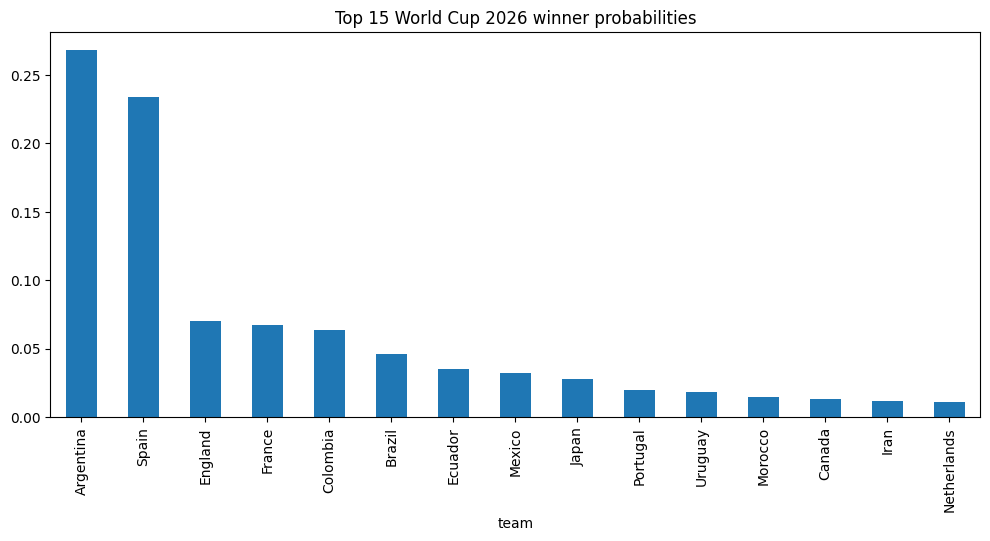

In [94]:
top_15 = df_final_probs.sort_values("winner_prob", ascending=False).head(15)

top_15.plot(
    x="team",
    y="winner_prob",
    kind="bar",
    figsize=(12, 5),
    legend=False,
    title="Top 15 World Cup 2026 winner probabilities"
)

## save final output

In [95]:
OUTPUT_PATH = PROCESSED_DIR / "wc2026_tournament_probabilities.csv"

df_final_probs.to_csv(OUTPUT_PATH, index=False)

print(f"Saved final tournament probabilities to: {OUTPUT_PATH}")

Saved final tournament probabilities to: ../data/processed/wc2026_tournament_probabilities.csv


In [96]:
df_final_probs.groupby("confederation")[["r16_prob", "qf_prob", "sf_prob", "final_prob", "winner_prob"]].mean()

,r16_prob,qf_prob,sf_prob,final_prob,winner_prob
confederation,,,,,
AFC,0.275111,0.118444,0.048111,0.018000,0.006111
CAF,0.161100,0.058000,0.021300,0.007900,0.002200
CONCACAF,0.362333,0.155667,0.060833,0.022333,0.008833
CONMEBOL,0.568667,0.362667,0.216667,0.128667,0.072500
OFC,0.318000,0.089000,0.016000,0.003000,0.001000
UEFA,0.375563,0.197187,0.104563,0.053125,0.027125


In [97]:
df_final_probs.groupby("confederation")["winner_prob"].sum()

confederation
AFC         0.055
CAF         0.022
CONCACAF    0.053
CONMEBOL    0.435
OFC         0.001
UEFA        0.434
Name: winner_prob, dtype: float64